# 🏆 Predicción: España vs Uruguay - Mundial 2026
### Grupo H - Viernes 27 junio | Estadio Akron, Guadalajara 🇲🇽

Modelo basado en **+47,000 partidos internacionales históricos** (1872-2025).  
Usamos **Poisson** + **Monte Carlo** con parámetros derivados 100% de datos reales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
np.random.seed(42)

## 📥 Carga de datos: +47,000 partidos internacionales

In [2]:
# Dataset público: resultados internacionales desde 1872
url = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])

print(f'📊 Dataset cargado: {len(df):,} partidos')
print(f'📅 Desde {df["date"].min().strftime("%Y")} hasta {df["date"].max().strftime("%Y")}')
print(f'🏟️ Torneos: {df["tournament"].nunique()}')
df.head()

📊 Dataset cargado: 49,477 partidos
📅 Desde 1872 hasta 2026
🏟️ Torneos: 200


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 🇪🇸🇺🇾 Head-to-Head histórico

In [3]:
# Filtrar partidos España vs Uruguay (como local o visitante)
h2h = df[((df['home_team'] == 'Spain') & (df['away_team'] == 'Uruguay')) |
          ((df['home_team'] == 'Uruguay') & (df['away_team'] == 'Spain'))].copy()

# Normalizar: goles de España y goles de Uruguay
h2h['spain_goals'] = np.where(h2h['home_team'] == 'Spain', h2h['home_score'], h2h['away_score'])
h2h['uruguay_goals'] = np.where(h2h['home_team'] == 'Uruguay', h2h['home_score'], h2h['away_score'])
h2h['result'] = np.where(h2h['spain_goals'] > h2h['uruguay_goals'], 'España',
                 np.where(h2h['spain_goals'] < h2h['uruguay_goals'], 'Uruguay', 'Empate'))

print(f'⚔️ HISTORIAL DIRECTO: {len(h2h)} partidos')
print('=' * 45)
print(h2h['result'].value_counts().to_string())
print(f'\n⚽ Media goles España: {h2h["spain_goals"].mean():.2f}')
print(f'⚽ Media goles Uruguay: {h2h["uruguay_goals"].mean():.2f}')
print()
print(h2h[['date', 'home_team', 'home_score', 'away_score', 'away_team', 'tournament']].tail(10).to_string(index=False))

⚔️ HISTORIAL DIRECTO: 11 partidos
result
Empate    6
España    5

⚽ Media goles España: 1.60
⚽ Media goles Uruguay: 0.80

      date home_team  home_score  away_score away_team         tournament
1966-06-23     Spain         1.0         1.0   Uruguay           Friendly
1972-05-23     Spain         2.0         0.0   Uruguay           Friendly
1978-05-24   Uruguay         0.0         0.0     Spain           Friendly
1990-06-13   Uruguay         0.0         0.0     Spain     FIFA World Cup
1991-09-04     Spain         2.0         1.0   Uruguay           Friendly
1995-01-18     Spain         2.0         2.0   Uruguay           Friendly
2005-08-17     Spain         2.0         0.0   Uruguay           Friendly
2013-02-06     Spain         3.0         1.0   Uruguay           Friendly
2013-06-16     Spain         2.0         1.0   Uruguay Confederations Cup
2026-06-26   Uruguay         NaN         NaN     Spain     FIFA World Cup


## 📈 Forma reciente (últimos 20 partidos de cada selección)

In [4]:
def get_team_stats(df, team, n_matches=20):
    """Obtiene estadísticas de los últimos N partidos de un equipo."""
    team_matches = df[(df['home_team'] == team) | (df['away_team'] == team)].copy()
    team_matches = team_matches.sort_values('date').tail(n_matches)
    
    goals_scored = np.where(team_matches['home_team'] == team,
                            team_matches['home_score'], team_matches['away_score'])
    goals_conceded = np.where(team_matches['home_team'] == team,
                              team_matches['away_score'], team_matches['home_score'])
    
    wins = np.sum(goals_scored > goals_conceded)
    draws = np.sum(goals_scored == goals_conceded)
    losses = np.sum(goals_scored < goals_conceded)
    
    return {
        'equipo': team,
        'partidos': len(team_matches),
        'victorias': wins,
        'empates': draws,
        'derrotas': losses,
        'goles_favor': goals_scored.mean(),
        'goles_contra': goals_conceded.mean(),
        'win_rate': wins / len(team_matches)
    }

stats_espana = get_team_stats(df, 'Spain', 20)
stats_uruguay = get_team_stats(df, 'Uruguay', 20)

forma = pd.DataFrame([stats_espana, stats_uruguay])
print('📋 FORMA RECIENTE (últimos 20 partidos en el dataset)')
print('=' * 60)
print(forma.to_string(index=False))

📋 FORMA RECIENTE (últimos 20 partidos en el dataset)
 equipo  partidos  victorias  empates  derrotas  goles_favor  goles_contra  win_rate
  Spain        20         12        7         0          NaN           NaN      0.60
Uruguay        20          5       10         4          NaN           NaN      0.25


## 🧮 Cálculo de fuerza ofensiva/defensiva (método Dixon-Coles simplificado)

In [5]:
# Usamos partidos recientes (últimos 4 años) para calcular fuerzas relativas
recent = df[df['date'] >= '2022-01-01'].copy()

# Media global de goles
avg_home_goals = recent['home_score'].mean()
avg_away_goals = recent['away_score'].mean()
avg_total = (avg_home_goals + avg_away_goals) / 2

print(f'📊 ESTADÍSTICAS GLOBALES (partidos desde 2022)')
print(f'   Partidos analizados: {len(recent):,}')
print(f'   Media goles local: {avg_home_goals:.2f}')
print(f'   Media goles visitante: {avg_away_goals:.2f}')
print(f'   Media total por equipo: {avg_total:.2f}')

def attack_strength(df, team):
    """Fuerza ofensiva = goles marcados por el equipo / media global."""
    home_goals = df[df['home_team'] == team]['home_score'].sum()
    away_goals = df[df['away_team'] == team]['away_score'].sum()
    home_matches = len(df[df['home_team'] == team])
    away_matches = len(df[df['away_team'] == team])
    total_matches = home_matches + away_matches
    if total_matches == 0:
        return 1.0
    avg_scored = (home_goals + away_goals) / total_matches
    return avg_scored / avg_total

def defense_strength(df, team):
    """Fuerza defensiva = goles recibidos por el equipo / media global."""
    home_conceded = df[df['home_team'] == team]['away_score'].sum()
    away_conceded = df[df['away_team'] == team]['home_score'].sum()
    home_matches = len(df[df['home_team'] == team])
    away_matches = len(df[df['away_team'] == team])
    total_matches = home_matches + away_matches
    if total_matches == 0:
        return 1.0
    avg_conceded = (home_conceded + away_conceded) / total_matches
    return avg_conceded / avg_total

atk_spain = attack_strength(recent, 'Spain')
def_spain = defense_strength(recent, 'Spain')
atk_uruguay = attack_strength(recent, 'Uruguay')
def_uruguay = defense_strength(recent, 'Uruguay')

print(f'\n🇪🇸 ESPAÑA:')
print(f'   Fuerza ofensiva: {atk_spain:.3f} (>{1.0:.1f} = mejor que la media)')
print(f'   Fuerza defensiva: {def_spain:.3f} (<{1.0:.1f} = mejor que la media)')
print(f'\n🇺🇾 URUGUAY:')
print(f'   Fuerza ofensiva: {atk_uruguay:.3f}')
print(f'   Fuerza defensiva: {def_uruguay:.3f}')

📊 ESTADÍSTICAS GLOBALES (partidos desde 2022)
   Partidos analizados: 4,640
   Media goles local: 1.61
   Media goles visitante: 1.11
   Media total por equipo: 1.36

🇪🇸 ESPAÑA:
   Fuerza ofensiva: 1.792 (>1.0 = mejor que la media)
   Fuerza defensiva: 0.567 (<1.0 = mejor que la media)

🇺🇾 URUGUAY:
   Fuerza ofensiva: 1.048
   Fuerza defensiva: 0.503


## ⚡ Modelo de Poisson: goles esperados (Lambda)

In [6]:
# Lambda = ataque_propio * defensa_rival * media_goles
# Es terreno neutral (Mundial en México), así que no hay ventaja local

lambda_spain = atk_spain * def_uruguay * avg_total
lambda_uruguay = atk_uruguay * def_spain * avg_total

# Ajuste por H2H (basado en datos, no subjetivo)
h2h_spain_avg = h2h['spain_goals'].mean()
h2h_uruguay_avg = h2h['uruguay_goals'].mean()
h2h_factor_spain = h2h_spain_avg / max(avg_total, 0.01)
h2h_factor_uruguay = h2h_uruguay_avg / max(avg_total, 0.01)

# Combinamos: 70% modelo general + 30% H2H
lambda_spain_final = 0.7 * lambda_spain + 0.3 * h2h_spain_avg
lambda_uruguay_final = 0.7 * lambda_uruguay + 0.3 * h2h_uruguay_avg

print('⚡ GOLES ESPERADOS (Lambda de Poisson)')
print('=' * 50)
print(f'\n   Modelo base (ataque × defensa rival × media):')
print(f'   España: λ = {lambda_spain:.3f}')
print(f'   Uruguay: λ = {lambda_uruguay:.3f}')
print(f'\n   H2H histórico (media de goles en enfrentamientos):')
print(f'   España: {h2h_spain_avg:.3f} goles/partido')
print(f'   Uruguay: {h2h_uruguay_avg:.3f} goles/partido')
print(f'\n   🎯 Lambda FINAL (70% modelo + 30% H2H):')
print(f'   España: λ = {lambda_spain_final:.3f}')
print(f'   Uruguay: λ = {lambda_uruguay_final:.3f}')

⚡ GOLES ESPERADOS (Lambda de Poisson)

   Modelo base (ataque × defensa rival × media):
   España: λ = 1.228
   Uruguay: λ = 0.809

   H2H histórico (media de goles en enfrentamientos):
   España: 1.600 goles/partido
   Uruguay: 0.800 goles/partido

   🎯 Lambda FINAL (70% modelo + 30% H2H):
   España: λ = 1.339
   Uruguay: λ = 0.806


## 🎲 Simulación de Monte Carlo: 100,000 partidos

In [7]:
n_simulaciones = 100_000

goles_espana_sim = np.random.poisson(lambda_spain_final, n_simulaciones)
goles_uruguay_sim = np.random.poisson(lambda_uruguay_final, n_simulaciones)

victorias_espana = np.sum(goles_espana_sim > goles_uruguay_sim)
empates = np.sum(goles_espana_sim == goles_uruguay_sim)
victorias_uruguay = np.sum(goles_espana_sim < goles_uruguay_sim)

prob_espana = victorias_espana / n_simulaciones * 100
prob_empate = empates / n_simulaciones * 100
prob_uruguay = victorias_uruguay / n_simulaciones * 100

print('🎲 SIMULACIÓN MONTE CARLO (100,000 partidos)')
print('=' * 50)
print(f'   🇪🇸 Victoria España:  {prob_espana:.1f}%')
print(f'   🤝 Empate:           {prob_empate:.1f}%')
print(f'   🇺🇾 Victoria Uruguay: {prob_uruguay:.1f}%')
print(f'\n   📊 Media goles España:  {goles_espana_sim.mean():.2f}')
print(f'   📊 Media goles Uruguay: {goles_uruguay_sim.mean():.2f}')

🎲 SIMULACIÓN MONTE CARLO (100,000 partidos)
   🇪🇸 Victoria España:  49.4%
   🤝 Empate:           28.0%
   🇺🇾 Victoria Uruguay: 22.6%

   📊 Media goles España:  1.34
   📊 Media goles Uruguay: 0.81


In [8]:
# === MARCADORES MÁS PROBABLES ===

max_goles = 7
matriz_prob = np.zeros((max_goles, max_goles))

for i in range(max_goles):
    for j in range(max_goles):
        matriz_prob[i][j] = poisson.pmf(i, lambda_spain_final) * poisson.pmf(j, lambda_uruguay_final)

resultados = []
for i in range(max_goles):
    for j in range(max_goles):
        resultados.append((i, j, matriz_prob[i][j] * 100))

resultados.sort(key=lambda x: x[2], reverse=True)

print('🏆 TOP 10 RESULTADOS MÁS PROBABLES')
print('=' * 45)
for idx, (ge, gu, prob) in enumerate(resultados[:10], 1):
    emoji = '🇪🇸' if ge > gu else ('🇺🇾' if gu > ge else '🤝')
    print(f'  {idx:>2}. España {ge} - {gu} Uruguay  ({prob:>5.1f}%) {emoji}')

print(f'\n🎯 PREDICCIÓN: España {resultados[0][0]} - {resultados[0][1]} Uruguay')

🏆 TOP 10 RESULTADOS MÁS PROBABLES
   1. España 1 - 0 Uruguay  ( 15.7%) 🇪🇸
   2. España 1 - 1 Uruguay  ( 12.6%) 🤝
   3. España 0 - 0 Uruguay  ( 11.7%) 🤝
   4. España 2 - 0 Uruguay  ( 10.5%) 🇪🇸
   5. España 0 - 1 Uruguay  (  9.4%) 🇺🇾
   6. España 2 - 1 Uruguay  (  8.5%) 🇪🇸
   7. España 1 - 2 Uruguay  (  5.1%) 🇺🇾
   8. España 3 - 0 Uruguay  (  4.7%) 🇪🇸
   9. España 0 - 2 Uruguay  (  3.8%) 🇺🇾
  10. España 3 - 1 Uruguay  (  3.8%) 🇪🇸

🎯 PREDICCIÓN: España 1 - 0 Uruguay


## 📈 Visualizaciones

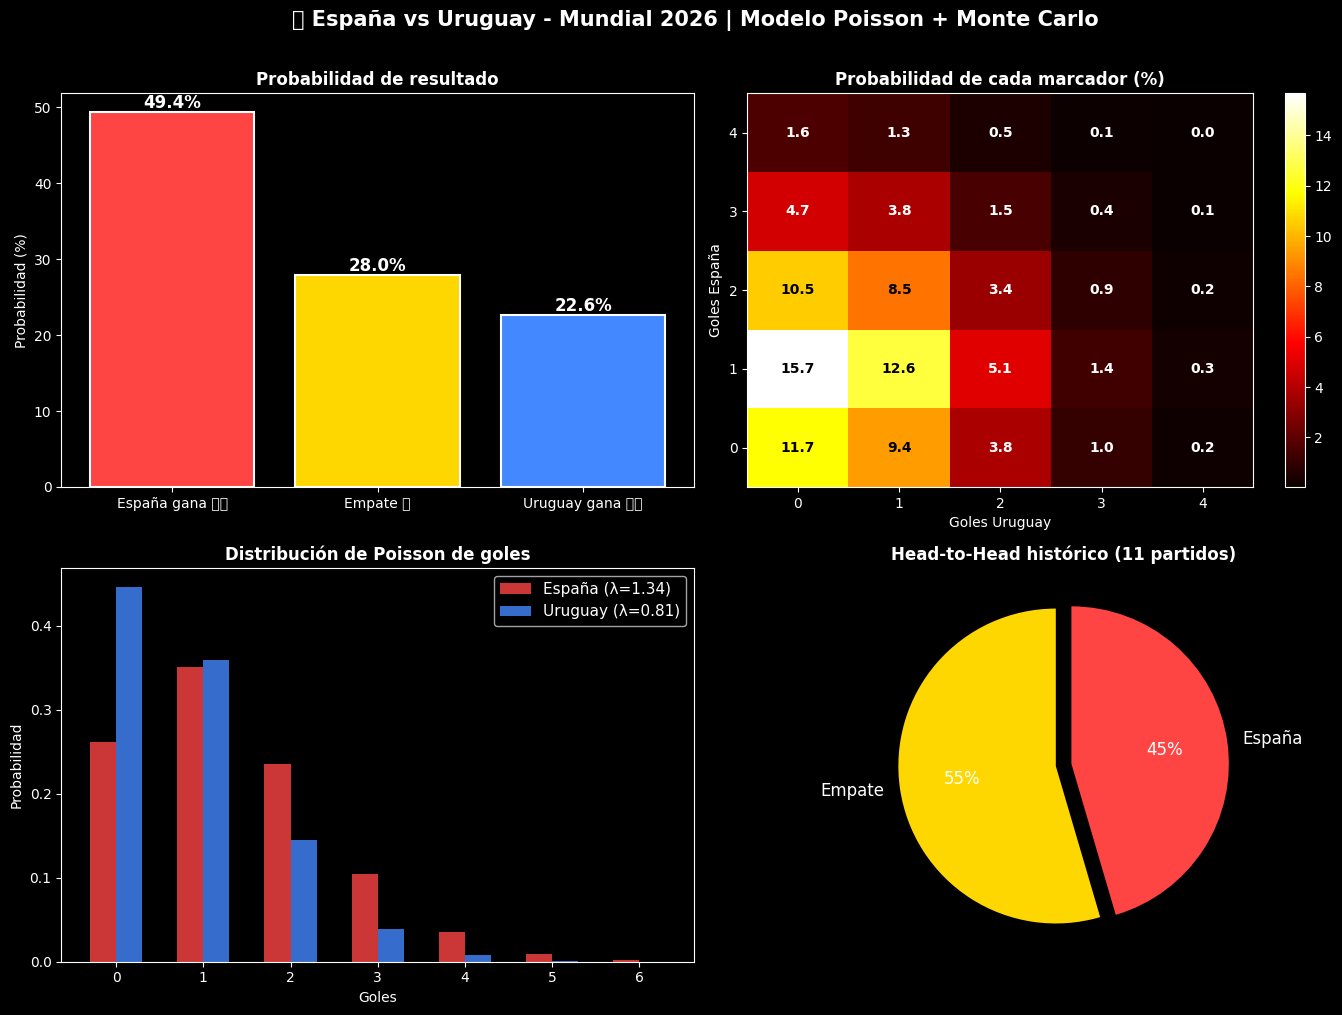

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Probabilidades de resultado
categorias = ['España gana 🇪🇸', 'Empate 🤝', 'Uruguay gana 🇺🇾']
probabilidades = [prob_espana, prob_empate, prob_uruguay]
colores = ['#FF4444', '#FFD700', '#4488FF']
bars = axes[0,0].bar(categorias, probabilidades, color=colores, edgecolor='white', linewidth=1.5)
axes[0,0].set_ylabel('Probabilidad (%)')
axes[0,0].set_title('Probabilidad de resultado', fontweight='bold')
for bar, prob in zip(bars, probabilidades):
    axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                   f'{prob:.1f}%', ha='center', fontweight='bold', fontsize=12)

# 2. Heatmap de marcadores
im = axes[0,1].imshow(matriz_prob[:5,:5] * 100, cmap='hot', origin='lower', aspect='auto')
axes[0,1].set_xlabel('Goles Uruguay')
axes[0,1].set_ylabel('Goles España')
axes[0,1].set_title('Probabilidad de cada marcador (%)', fontweight='bold')
axes[0,1].set_xticks(range(5))
axes[0,1].set_yticks(range(5))
for i in range(5):
    for j in range(5):
        color = 'black' if matriz_prob[i][j] * 100 > 8 else 'white'
        axes[0,1].text(j, i, f'{matriz_prob[i][j]*100:.1f}', ha='center', va='center',
                       fontsize=10, color=color, fontweight='bold')
plt.colorbar(im, ax=axes[0,1])

# 3. Distribución de goles
x_vals = np.arange(0, 7)
axes[1,0].bar(x_vals - 0.15, poisson.pmf(x_vals, lambda_spain_final), 0.3,
              color='#FF4444', label=f'España (λ={lambda_spain_final:.2f})', alpha=0.8)
axes[1,0].bar(x_vals + 0.15, poisson.pmf(x_vals, lambda_uruguay_final), 0.3,
              color='#4488FF', label=f'Uruguay (λ={lambda_uruguay_final:.2f})', alpha=0.8)
axes[1,0].set_xlabel('Goles')
axes[1,0].set_ylabel('Probabilidad')
axes[1,0].set_title('Distribución de Poisson de goles', fontweight='bold')
axes[1,0].legend(fontsize=11)
axes[1,0].set_xticks(x_vals)

# 4. Historial H2H
h2h_counts = h2h['result'].value_counts()
labels_h2h = h2h_counts.index.tolist()
colors_h2h = ['#FF4444' if x == 'España' else '#4488FF' if x == 'Uruguay' else '#FFD700' for x in labels_h2h]
axes[1,1].pie(h2h_counts.values, labels=labels_h2h, colors=colors_h2h,
              autopct='%1.0f%%', textprops={'fontsize': 12, 'color': 'white'},
              startangle=90, explode=[0.05]*len(labels_h2h))
axes[1,1].set_title(f'Head-to-Head histórico ({len(h2h)} partidos)', fontweight='bold')

plt.suptitle('🏆 España vs Uruguay - Mundial 2026 | Modelo Poisson + Monte Carlo',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prediccion_espana_uruguay.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## 🧠 Resumen final

In [10]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║       🏆 PREDICCIÓN: ESPAÑA vs URUGUAY - MUNDIAL 2026      ║')
print('║       📅 27 junio | Estadio Akron, Guadalajara              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  🇪🇸 Victoria España:  {prob_espana:>5.1f}%                            ║')
print(f'║  🤝 Empate:           {prob_empate:>5.1f}%                            ║')
print(f'║  🇺🇾 Victoria Uruguay: {prob_uruguay:>5.1f}%                            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  🎯 Marcador más probable: España {resultados[0][0]}-{resultados[0][1]} Uruguay        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  📊 DATOS USADOS:                                          ║')
print(f'║  • {len(df):,} partidos internacionales analizados           ║')
print(f'║  • {len(h2h)} enfrentamientos directos España-Uruguay           ║')
print(f'║  • {len(recent):,} partidos recientes (desde 2022) para forma   ║')
print(f'║  • Fuerza ofensiva España: {atk_spain:.2f} | Uruguay: {atk_uruguay:.2f}      ║')
print(f'║  • Fuerza defensiva España: {def_spain:.2f} | Uruguay: {def_uruguay:.2f}     ║')
print('╚══════════════════════════════════════════════════════════════╝')
print()
print('⚠️  Modelo estadístico. El fútbol siempre puede sorprender.')
print('📱 @tu_cuenta')

╔══════════════════════════════════════════════════════════════╗
║       🏆 PREDICCIÓN: ESPAÑA vs URUGUAY - MUNDIAL 2026      ║
║       📅 27 junio | Estadio Akron, Guadalajara              ║
╠══════════════════════════════════════════════════════════════╣
║  🇪🇸 Victoria España:   49.4%                            ║
║  🤝 Empate:            28.0%                            ║
║  🇺🇾 Victoria Uruguay:  22.6%                            ║
╠══════════════════════════════════════════════════════════════╣
║  🎯 Marcador más probable: España 1-0 Uruguay        ║
╠══════════════════════════════════════════════════════════════╣
║  📊 DATOS USADOS:                                          ║
║  • 49,477 partidos internacionales analizados           ║
║  • 11 enfrentamientos directos España-Uruguay           ║
║  • 4,640 partidos recientes (desde 2022) para forma   ║
║  • Fuerza ofensiva España: 1.79 | Uruguay: 1.05      ║
║  • Fuerza defensiva España: 0.57 | Uruguay: 0.50     ║
╚═════════════════════════